# Linear-equivalent disc / annulus with cone linearization
**The experiment.** Every natural-image patch is shown three ways, interleaved:

| `stimulusTag` | what it is |
|---|---|
| `image` | the image patch itself |
| `intensity` | uniform disc at the linear-equivalent intensity (patch averaged over the RF) |
| `linConeIntensity` / `lin cone intensity` | uniform disc at the **cone-linearized** equivalent intensity — averaged after a Weber cone nonlinearity `I / (I + WeberConstant)` |

Comparing image against each disc asks how much of the cell's preference for the real image
survives when the averaging happens in cone-response space instead of intensity space. The
measure is the nonlinearity index per patch, exactly as `computeNLI` defines it:

$$\mathrm{NLI} = \frac{\mathrm{image} - \mathrm{disc}}{|\mathrm{image}| + |\mathrm{disc}|}$$

set to zero when neither response clears a recording-mode threshold

In [ ]:
import retinanalysis as ra
import numpy as np
import pandas as pd

from retinanalysis.SCutils import explore as sc
from retinanalysis.SCutils.protocols import linear_equivalent_disc as led

## 1. Find experiment dates and cells for one protocol

Set `PROC` to one of the three exact protocol names below. This fast lookup shows only the
unique `exp_name`, `cell_label`, and short `protocol` rows. For `LinearEquivalentDisc`,
blocks without the `linearizeCones` option are the older unrelated experiment and are excluded.

In [ ]:
# Choose exactly one:
# 'LinearEquivalentAnnulus', 'LinearEquivalentDiscConeLin', or 'LinearEquivalentDisc'
PROC = 'LinearEquivalentAnnulus'

protocol_cells = led.find_protocol_cells(PROC)

331 blocks | 23 experiments | 57 cells
  dropped 363 LinearEquivalentDisc block(s) with no linearizeCones parameter (the older, unrelated protocol)
  by protocol: LinearEquivalentDiscConeLin 159, LinearEquivalentAnnulus 114, LinearEquivalentDisc 58


exp_name,cell_label,cell_type_short,protocol,site,onlineAnalysis,filter_wheel_ndf,backgroundIntensity,light_setting,WeberConstant,n_epochs,block_id
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15212
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15213
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15214
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15215
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15216
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.17587341735484144,FW0/bg0.175873,2000.0,90,15217
2026-03-09_E,Cell1,OFF-parasol,LinearEquivalentDisc,center,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15225
2026-03-09_E,Cell2,ON-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15175
2026-03-09_E,Cell2,ON-parasol,LinearEquivalentAnnulus,surround,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,180,15176
2026-03-09_E,Cell3,horizontal,LinearEquivalentDisc,center,none,0.0,0.1822633339669877,FW0/bg0.182263,2000.0,90,15186


In [ ]:
# `protocol_cells` contains exp_name, cell_label, and the short protocol name.

### 1b. Resolve the recording mode from the amplifier

Some blocks have `onlineAnalysis` left at `none`, and a few recorded labels are wrong.
Grouping or analyzing on that label would put spiking and voltage-clamp recordings in the
same bucket.

The amplifier says what the rig actually did. Symphony writes
`stimulus:Amp1:seriesResistance` into every epoch — exactly 0 for a cell-attached patch, which
has no access resistance, and positive for whole-cell. `check_series_resistance` is the same
function the flashed-grating notebook uses, and it resolves three situations:

- **Label never set (`none`).** Nothing to contradict, so the reading decides outright: positive
  Rs means whole-cell, with the holding potential read off the sign of the current (inward is
  `exc`, outward `inh`); Rs of 0 means cell-attached if the trace has spikes, and whole-cell with
  the field simply never filled in if it does not.
- **Label set but contradicted.** The reading wins and the block is relabelled — a mislabelled
  cell-attached recording gets spike sorted, a mislabelled whole-cell one gets treated as current.
- **Above 20 MΩ.** The recorded current is too filtered to trust, so the block is dropped.

Whatever the label says, `analyze_group` applies the same rule per block, so the analysis is
right even if you skip this cell. Running it here is what makes the *grouping* right — and it
leaves the recorded label in `onlineAnalysis_recorded` so nothing is lost.

Only blocks for the selected `PROC` are loaded below. The database lookup is batched; resolving
recording mode still needs the raw traces and is therefore the intentionally slower step.

In [ ]:
df_blocks = led.find_blocks(protocols=[PROC], show=False)
df_blocks = led.check_series_resistance(df_blocks)

print('\nresolved onlineAnalysis (what each block is actually analyzed as)')
display(pd.crosstab(df_blocks['onlineAnalysis_recorded'], df_blocks['onlineAnalysis'],
                    rownames=['recorded'], colnames=['resolved to']))

## 2. Group into recordings

One row per experiment × cell × recording mode × disc site × light level. Blocks in a group are
pooled, so a cell recorded across several blocks at one light level yields one set of patches.

The mode grouped on is the one section 1b resolved, not the recorded label — otherwise the 142
`none` blocks would land in a single bucket regardless of how those cells were held. What the
experimenter actually typed survives in `recorded_labels`, so a group made up of blocks that were
never labelled is visible as such. If you skipped 1b the cell says so rather than grouping on a
label nobody set.

The table also carries `max_intensity` (the display ceiling the patch intensities are scaled
against), `stage_ndfs` (the fixed neutral-density filters in the light path, which the filter
wheel setting does not imply) and the series resistance behind the mode decision.

In [4]:
groups = led.group_blocks(df_blocks)

174 recording groups (experiment x cell x mode x site x light level)


exp_name,cell_label,cell_type_short,onlineAnalysis,site,filter_wheel_ndf,backgroundIntensity,blocks,epochs,protocols,light_setting,rstar,light_level,weber,block_ids
2026-05-08_E,Cell4,OFF-midget,extracellular,center,,0.22124520248819152,9,1457,LinearEquivalentDiscConeLin,FW?/bg0.221245,,FW?/bg0.221245 (?R*),2000.0,"33290, 33291, 33292, 33295, 33296, 33297, 33298, 33299, 33300"
2026-06-29_E,Cell2,,extracellular,surround,0.0,0.1822633339669877,1,113,LinearEquivalentAnnulus,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,33783
,,,extracellular,surround,0.0,0.1390552212837207,2,319,LinearEquivalentAnnulus,FW0/bg0.139055,,FW0/bg0.139055 (?R*),2000.0,"33784, 33785"
,,,extracellular,surround,0.0,0.14730007774913503,2,308,LinearEquivalentAnnulus,FW0/bg0.1473,,FW0/bg0.1473 (?R*),2000.0,"33786, 33787"
,,,extracellular,surround,0.0,0.19940717249547127,1,180,LinearEquivalentAnnulus,FW0/bg0.199407,,FW0/bg0.199407 (?R*),2000.0,33791
,Cell4,,extracellular,surround,0.0,0.17587341735484144,1,180,LinearEquivalentAnnulus,FW0/bg0.175873,,FW0/bg0.175873 (?R*),2000.0,33761
2026-06-30_E,Cell4,,extracellular,surround,0.0,0.11507195997438452,3,172,LinearEquivalentAnnulus,FW0/bg0.115072,,FW0/bg0.115072 (?R*),2000.0,"33831, 33832, 33833"
2026-03-09_E,Cell1,OFF-parasol,none,surround,0.0,0.1822633339669877,3,270,LinearEquivalentAnnulus,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,"15212, 15213, 15214"
,,,none,surround,0.0,0.17587341735484144,3,270,LinearEquivalentAnnulus,FW0/bg0.175873,,FW0/bg0.175873 (?R*),2000.0,"15215, 15216, 15217"
,,,none,center,0.0,0.1822633339669877,1,90,LinearEquivalentDisc,FW0/bg0.182263,,FW0/bg0.182263 (?R*),2000.0,15225


## 3. What the cell was shown

The three stimuli for one patch, on a common grey scale: the natural-image patch as seen through
the aperture, the uniform disc at the linear-equivalent intensity, and the uniform disc at the
cone-linearized intensity. The image is loaded from the van Hateren resources in the turner
package the same way `NaturalImageFlashProtocol.m` does — big-endian `.iml`, rescaled so the
brightest pixel is 1, at 6.6 µm per image pixel.

A useful check that the geometry is right: the mean intensity inside the aperture should land on
the recorded `equivalentIntensity`, since that is what the equivalent disc is defined to be.

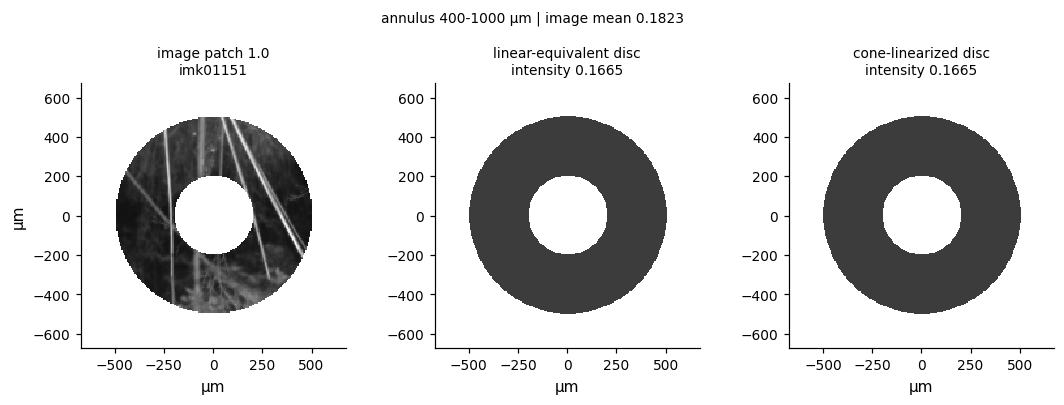

In [5]:
example = led.example_patch_params(df_blocks.exp_name.iloc[0],
                                   int(df_blocks.block_id.iloc[0]))
led.plot_stimulus_example(example);

## 3. Analyze one recording

Per epoch the onset and offset responses are measured, then averaged within
(image, patch, stimulus category). A patch is kept only if it has an image trial and at least
one disc trial. Left: each patch's image response against its two discs, with the unity line —
points above it are patches where the real image drove the cell more than the equivalent
uniform disc. Right: the NLI values those produce.

2026-04-15_E/Cell1  |  ON-parasol  |  7 recording condition(s), 13 blocks, 1661 epochs
  varies across conditions: onlineAnalysis = exc, extracellular, none; site = center, surround; protocols = LinearEquivalentAnnulus, LinearEquivalentDiscConeLin; light_setting = FW0/bg0.139055, FW0/bg0.175873, FW0/bg0.199407; light_level = FW0/bg0.139055 (?R*), FW0/bg0.175873 (?R*), FW0/bg0.199407 (?R*); backgroundIntensity = 0.1390552212837207, 0.17587341735484144, 0.19940717249547127


onlineAnalysis,site,protocols,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,weber,blocks,epochs,block_ids
extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,2,4,"34084, 34085"
none,surround,LinearEquivalentAnnulus,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,5,755,"34086, 34087, 34088, 34116, 34118"
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.139055,FW0/bg0.139055 (?R*),0.0,0.1390552212837207,2000.0,1,180,34108
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,1,180,34109
exc,center,LinearEquivalentDiscConeLin,FW0/bg0.175873,FW0/bg0.175873 (?R*),0.0,0.17587341735484144,2000.0,1,180,34110
exc,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,1,2,34111
none,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,2,360,"34112, 34115"


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 1020 peaks


Trial 1: Found 23 spikes
Trial 2: Found 1024 peaks
Trial 2: Found 18 spikes
Trial 3: Found 992 peaks
Trial 3: Found 24 spikes
Trial 4: Found 1032 peaks
Trial 4: Found 14 spikes
Trial 5: Found 1030 peaks
Trial 5: Found 12 spikes
Trial 6: Found 1051 peaks
Trial 6: Found 14 spikes
Trial 7: Found 1028 peaks
Trial 7: Found 16 spikes
Trial 8: Found 1056 peaks
Trial 8: Found 8 spikes
Trial 9: Found 1003 peaks


...

Trial 26: Found 18 spikes
Trial 27: Found 989 peaks
Trial 27: Found 13 spikes
Trial 28: Found 963 peaks
Trial 28: Found 19 spikes
Trial 29: Found 961 peaks
Trial 29: Found 12 spikes
Trial 30: Found 986 peaks
Trial 30: Found 23 spikes
Trial 31: Found 945 peaks
Trial 31: Found 17 spikes
Trial 32: Found 974 peaks
Trial 32: Found 14 spikes
Trial 33: Found 968 peaks
Trial 33: Found 17 spikes
Trial 34: Found 963 peaks


Trial 34: Found 16 spikes
Trial 35: Found 991 peaks
Trial 35: Found 12 spikes


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


2026-04-15_E | RGC\ON-parasol | Cell1 | exc | disc over surround | FW0/bg0.139055 | 30 patches, 755 epochs
  NLI standard disc : onset -0.234  offset -0.174
  NLI cone-lin disc : onset +0.049  offset -0.150


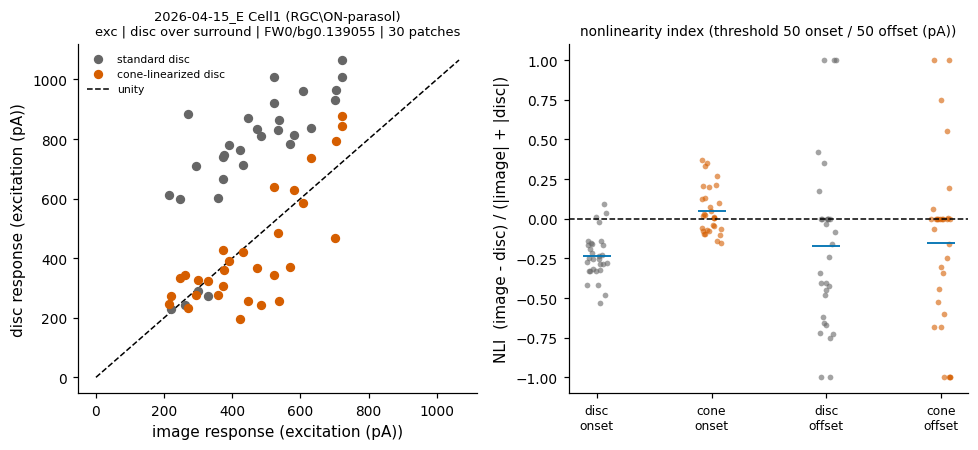

In [6]:
row = groups.sort_values('epochs', ascending=False).iloc[2]

# Before analyzing a single recording, see what else this cell has: the other
# conditions it was recorded in, and whether the one picked is representative.
led.describe_cell(f'{row.exp_name}/{row.cell_label}', groups)

rec = led.analyze_group(row.exp_name, [int(b) for b in row.block_ids.split(',')],
                        online_analysis=row.onlineAnalysis)
led.plot_group(rec);

## 4. Batch analyze and save

Records go to `<OUTPUT_DIR>/linear_equivalent_disc/records.h5` with a `summary.csv` index,
upserted per (experiment, cell, mode, site, filter wheel, background) — same layout as the other
protocols, in its own directory. `skip_existing` makes re-running the notebook cheap.

In [7]:
records = led.analyze_all(groups, save=True, plot=False, skip_existing=True)

If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 1252 peaks
Trial 1: Found 1 spikes
Trial 2: Found 1272 peaks
Trial 2: Found 6 spikes
Trial 3: Found 1274 peaks
Trial 3: Found 8 spikes
Trial 4: Found 1269 peaks
Trial 4: Found 6 spikes
Trial 5: Found 1280 peaks


Trial 5: Found 9 spikes
Trial 6: Found 1289 peaks
Trial 6: Found 8 spikes
Trial 7: Found 1275 peaks
Trial 7: Found 4 spikes
Trial 8: Found 1281 peaks
Trial 8: Found 8 spikes
Trial 9: Found 1268 peaks
Trial 9: Found 6 spikes
Trial 10: Found 1260 peaks
Trial 10: Found 2 spikes
Trial 11: Found 1277 peaks


Trial 11: Found 8 spikes
Trial 12: Found 1276 peaks
Trial 12: Found 5 spikes
Trial 13: Found 1310 peaks
Trial 13: Found 5 spikes
Trial 14: Found 1281 peaks
Trial 14: Found 8 spikes
Trial 15: Found 1281 peaks
Trial 15: Found 4 spikes
Trial 16: Found 1289 peaks
Trial 16: Found 2 spikes
Trial 17: Found 1289 peaks


Trial 17: Found 7 spikes
Trial 18: Found 1311 peaks
Trial 18: Found 5 spikes
Trial 19: Found 1298 peaks
Trial 19: Found 2 spikes
Trial 20: Found 1307 peaks
Trial 20: Found 6 spikes
Trial 21: Found 1298 peaks
Trial 21: Found 4 spikes
Trial 22: Found 1318 peaks
Trial 22: Found 1 spikes
Trial 23: Found 1307 peaks


...

Trial 150: Found 24 spikes
Trial 151: Found 942 peaks
Trial 151: Found 24 spikes
Trial 152: Found 951 peaks
Trial 152: Found 24 spikes
Trial 153: Found 965 peaks
Trial 153: Found 21 spikes
Trial 154: Found 938 peaks
Trial 154: Found 21 spikes
Trial 155: Found 929 peaks
Trial 155: Found 21 spikes
Trial 156: Found 931 peaks
Trial 156: Found 20 spikes
Trial 157: Found 959 peaks
Trial 157: Found 18 spikes
Trial 158: Found 983 peaks
Trial 158: Found 15 spikes
Trial 159: Found 976 peaks


Trial 159: Found 13 spikes
Trial 160: Found 952 peaks
Trial 160: Found 24 spikes
Trial 161: Found 930 peaks
Trial 161: Found 29 spikes
Trial 162: Found 924 peaks
Trial 162: Found 26 spikes
Trial 163: Found 984 peaks
Trial 163: Found 14 spikes
Trial 164: Found 993 peaks
Trial 164: Found 18 spikes
Trial 165: Found 982 peaks
Trial 165: Found 18 spikes
Trial 166: Found 967 peaks
Trial 166: Found 15 spikes
Trial 167: Found 977 peaks


Trial 167: Found 19 spikes
Trial 168: Found 961 peaks
Trial 168: Found 18 spikes
Trial 169: Found 983 peaks
Trial 169: Found 15 spikes
Trial 170: Found 952 peaks
Trial 170: Found 18 spikes
Trial 171: Found 950 peaks
Trial 171: Found 14 spikes
Trial 172: Found 974 peaks
Trial 172: Found 15 spikes
Trial 173: Found 971 peaks
Trial 173: Found 13 spikes
Trial 174: Found 995 peaks
Trial 174: Found 12 spikes
Trial 175: Found 939 peaks
Trial 175: Found 18 spikes
Trial 176: Found 967 peaks


Trial 176: Found 16 spikes
Trial 177: Found 938 peaks
Trial 177: Found 20 spikes
Trial 178: Found 929 peaks
Trial 178: Found 24 spikes
Trial 179: Found 919 peaks
Trial 179: Found 24 spikes
Trial 180: Found 952 peaks
Trial 180: Found 23 spikes


analyzed 74/174 groups (100 already stored, skipped)


## 5. Population: does cone linearization remove the nonlinearity?

Section 1 of `populationLinConeDisc.m`: one line per recording joining its mean standard-disc
NLI to its mean cone-linearized NLI, per recording mode, with a paired Wilcoxon signed-rank
test. If cone linearization captures what the cell is doing, the cone-linearized NLI should sit
closer to zero.

172 stored recordings


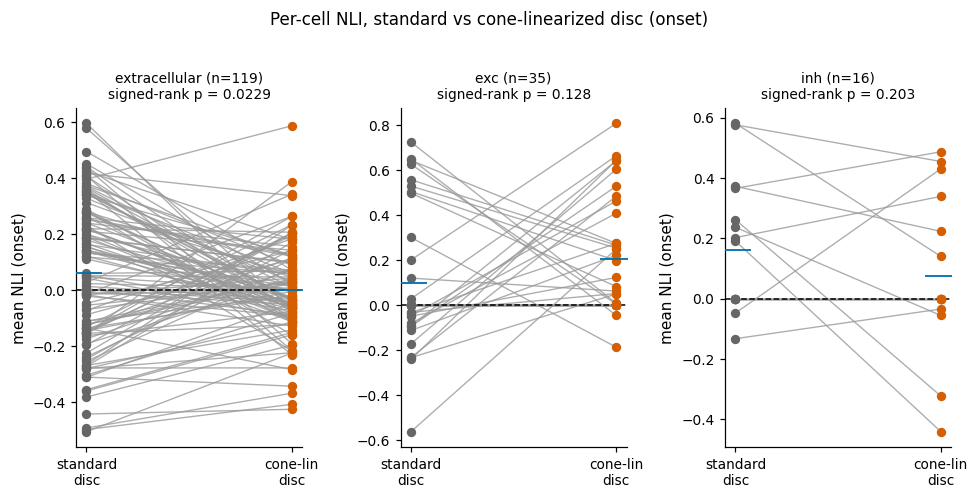

In [8]:
summary = led.load_summary()
print(f'{len(summary)} stored recordings')
led.plot_population_nli(summary, window='onset');

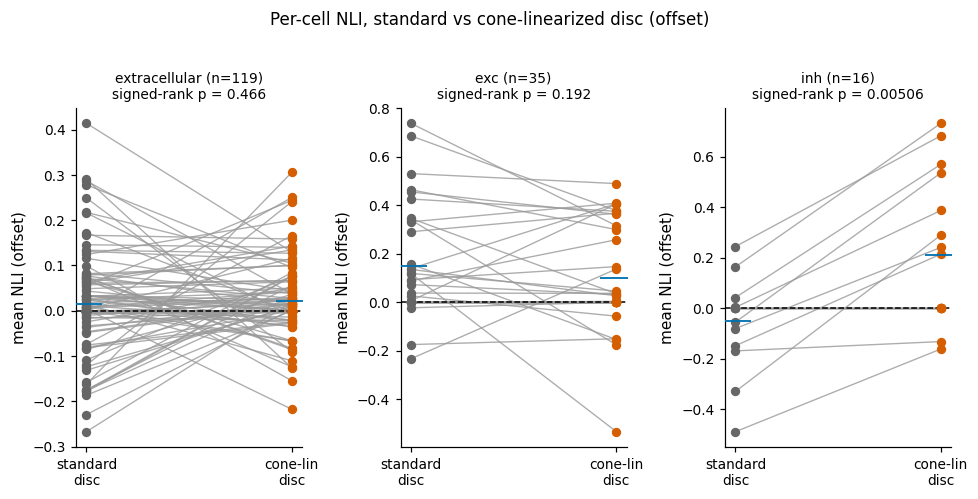

In [9]:
led.plot_population_nli(summary, window='offset');

### Pooled per-patch distributions

Section 2 of the population script — every patch from every recording, no per-cell averaging,
with a two-sample KS test.

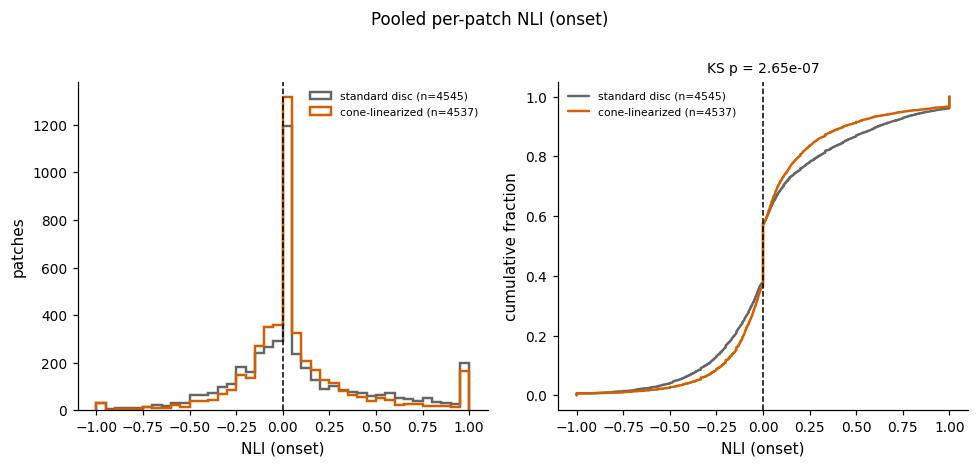

In [10]:
led.plot_nli_distributions(window='onset');

### Split by disc site

The annulus protocol puts the disc over the surround; the other two put it over the centre.
Those are different experiments and are worth looking at separately.

In [11]:
for site in sorted(summary['site'].unique()):
    sub = summary[summary['site'].eq(site)]
    print(f'--- disc over {site}: {len(sub)} recordings ---')
    display(sub.groupby('online_analysis')[['nli_disc_onset', 'nli_cone_onset',
                                            'nli_disc_offset', 'nli_cone_offset']]
               .agg(['count', 'mean']).round(3))

--- disc over center: 113 recordings ---


nli_disc_onset        nli_cone_onset        nli_disc_offset  \
                         count   mean          count   mean           count   
online_analysis                                                               
exc                         29  0.061             29  0.232              29   
extracellular               69  0.116             69  0.036              69   
inh                         15  0.183             15  0.084              15   

                       nli_cone_offset         
                  mean           count   mean  
online_analysis                                
exc              0.184              29  0.116  
extracellular    0.046              69  0.020  
inh             -0.043              15  0.233

--- disc over surround: 59 recordings ---


nli_disc_onset        nli_cone_onset        nli_disc_offset  \
                         count   mean          count   mean           count   
online_analysis                                                               
exc                          7  0.243              6  0.065               7   
extracellular               51 -0.009             50 -0.050              51   
inh                          1 -0.133              1 -0.034               1   

                       nli_cone_offset         
                  mean           count   mean  
online_analysis                                
exc             -0.023               6  0.014  
extracellular   -0.030              50  0.025  
inh             -0.169               1 -0.132

## 6. Come back later

`load_summary()` reads the scalar index with no DataJoint or SSD access; `load_records()` pulls
the per-patch arrays.

In [ ]:
cols = ['exp_name', 'cell_label', 'cell_type', 'online_analysis', 'online_analysis_recorded',
        'site', 'light_setting', 'max_intensity', 'series_resistance', 'n_patches',
        'nli_disc_onset', 'nli_cone_onset']
sc.scroll_table(summary[[c for c in cols if c in summary.columns]], height=320)

## Inspect one cell

Everything above runs across the whole dataset. This section goes the other way: name a single
cell and see every recording of it, split by condition.

A cell is identified by `'<experiment>/<cell label>'`, e.g. `'2026-04-03_E/Cell4'`. `list_cells` shows the
available ids together with the conditions each cell was recorded in — recording mode, site,
light setting, and whatever else varies for this protocol — so you can pick one. A bare cell
label also works when it is unambiguous.

In [13]:
led.list_cells(groups)

57 cells, 174 recording conditions in total


cell_id,cell_type,conditions,epochs,onlineAnalysis,site,protocols,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,weber
2026-05-08_E/Cell4,OFF-midget,1,1457,extracellular,center,LinearEquivalentDiscConeLin,FW?/bg0.221245,FW?/bg0.221245 (?R*),nan,0.22124520248819152,2000.0
2026-06-29_E/Cell2,,4,920,extracellular,surround,LinearEquivalentAnnulus,"FW0/bg0.139055, FW0/bg0.1473, FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.139055 (?R*), FW0/bg0.1473 (?R*), FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*)",0.0,"0.1390552212837207, 0.14730007774913503, 0.1822633339669877, 0.19940717249547127",2000.0
2026-06-29_E/Cell4,,1,180,extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.175873,FW0/bg0.175873 (?R*),0.0,0.17587341735484144,2000.0
2026-06-30_E/Cell4,,1,172,extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.115072,FW0/bg0.115072 (?R*),0.0,0.11507195997438452,2000.0
2026-03-09_E/Cell1,OFF-parasol,3,630,none,"center, surround","LinearEquivalentAnnulus, LinearEquivalentDisc","FW0/bg0.175873, FW0/bg0.182263","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*)",0.0,"0.17587341735484144, 0.1822633339669877",2000.0
2026-03-10_E/Cell2,,2,360,none,surround,LinearEquivalentAnnulus,"FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*)",0.0,"0.1822633339669877, 0.19940717249547127",2000.0
2026-03-10_E/Cell7,,1,180,none,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0
2026-03-17_E/Cell1,,1,80,none,surround,LinearEquivalentAnnulus,FW0/bg0.182263,FW0/bg0.182263 (?R*),0.0,0.1822633339669877,2000.0
2026-03-17_E/Cell2,,3,990,none,surround,LinearEquivalentAnnulus,"FW0/bg0.175873, FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*)",0.0,"0.17587341735484144, 0.1822633339669877, 0.19940717249547127",2000.0
2026-03-17_E/Cell6,,3,720,none,center,LinearEquivalentDisc,"FW0/bg0.175873, FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*)",0.0,"0.17587341735484144, 0.1822633339669877, 0.19940717249547127",2000.0


,cell_id,cell_type,conditions,epochs,onlineAnalysis,site,protocols,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,weber
0,2026-05-08_E/Cell4,OFF-midget,1,1457,extracellular,center,LinearEquivalentDiscConeLin,FW?/bg0.221245,FW?/bg0.221245 (?R*),nan,0.22124520248819152,2000.0
1,2026-06-29_E/Cell2,OFF-midget,4,920,extracellular,surround,LinearEquivalentAnnulus,"FW0/bg0.139055, FW0/bg0.1473, FW0/bg0.182263, ...","FW0/bg0.139055 (?R*), FW0/bg0.1473 (?R*), FW0/...",0.0,"0.1390552212837207, 0.14730007774913503, 0.182...",2000.0
2,2026-06-29_E/Cell4,OFF-midget,1,180,extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.175873,FW0/bg0.175873 (?R*),0.0,0.17587341735484144,2000.0
3,2026-06-30_E/Cell4,OFF-midget,1,172,extracellular,surround,LinearEquivalentAnnulus,FW0/bg0.115072,FW0/bg0.115072 (?R*),0.0,0.11507195997438452,2000.0
4,2026-03-09_E/Cell1,OFF-parasol,3,630,none,"center, surround","LinearEquivalentAnnulus, LinearEquivalentDisc","FW0/bg0.175873, FW0/bg0.182263","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*)",0.0,"0.17587341735484144, 0.1822633339669877",2000.0
5,2026-03-10_E/Cell2,OFF-parasol,2,360,none,surround,LinearEquivalentAnnulus,"FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*)",0.0,"0.1822633339669877, 0.19940717249547127",2000.0
6,2026-03-10_E/Cell7,OFF-parasol,1,180,none,surround,LinearEquivalentAnnulus,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0
7,2026-03-17_E/Cell1,OFF-parasol,1,80,none,surround,LinearEquivalentAnnulus,FW0/bg0.182263,FW0/bg0.182263 (?R*),0.0,0.1822633339669877,2000.0
8,2026-03-17_E/Cell2,OFF-parasol,3,990,none,surround,LinearEquivalentAnnulus,"FW0/bg0.175873, FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*), FW...",0.0,"0.17587341735484144, 0.1822633339669877, 0.199...",2000.0
9,2026-03-17_E/Cell6,OFF-parasol,3,720,none,center,LinearEquivalentDisc,"FW0/bg0.175873, FW0/bg0.182263, FW0/bg0.199407","FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*), FW...",0.0,"0.17587341735484144, 0.1822633339669877, 0.199...",2000.0


2026-04-03_E/Cell4  |  OFF-parasol  |  12 recording condition(s), 19 blocks, 2947 epochs
  varies across conditions: onlineAnalysis = extracellular, none; site = center, surround; protocols = LinearEquivalentAnnulus, LinearEquivalentDisc; light_setting = FW0.5/bg0.175873, FW0.5/bg0.182263, FW0.5/bg0.199407, FW0/bg0.175873, FW0/bg0.182263, FW0/bg0.199407, FW1/bg0.175873, FW1/bg0.199407; light_level = FW0.5/bg0.175873 (?R*), FW0.5/bg0.182263 (?R*), FW0.5/bg0.199407 (?R*), FW0/bg0.175873 (?R*), FW0/bg0.182263 (?R*), FW0/bg0.199407 (?R*), FW1/bg0.175873 (?R*), FW1/bg0.199407 (?R*); filter_wheel_ndf = 0.0, 0.5, 1.0; backgroundIntensity = 0.17587341735484144, 0.1822633339669877, 0.19940717249547127


onlineAnalysis,site,protocols,light_setting,light_level,filter_wheel_ndf,backgroundIntensity,weber,blocks,epochs,block_ids
none,center,LinearEquivalentDisc,FW1/bg0.175873,FW1/bg0.175873 (?R*),1.0,0.17587341735484144,2000.0,2,360,"15731, 15732"
none,center,LinearEquivalentDisc,FW0.5/bg0.175873,FW0.5/bg0.175873 (?R*),0.5,0.17587341735484144,2000.0,1,180,15734
none,center,LinearEquivalentDisc,FW0/bg0.175873,FW0/bg0.175873 (?R*),0.0,0.17587341735484144,2000.0,2,326,"15736, 15737"
extracellular,center,LinearEquivalentDisc,FW0/bg0.182263,FW0/bg0.182263 (?R*),0.0,0.1822633339669877,2000.0,2,5,"15741, 15742"
none,center,LinearEquivalentDisc,FW0/bg0.182263,FW0/bg0.182263 (?R*),0.0,0.1822633339669877,2000.0,1,180,15743
none,center,LinearEquivalentDisc,FW0.5/bg0.182263,FW0.5/bg0.182263 (?R*),0.5,0.1822633339669877,2000.0,1,180,15744
none,center,LinearEquivalentDisc,FW0.5/bg0.199407,FW0.5/bg0.199407 (?R*),0.5,0.19940717249547127,2000.0,2,360,"15745, 15757"
none,center,LinearEquivalentDisc,FW0/bg0.199407,FW0/bg0.199407 (?R*),0.0,0.19940717249547127,2000.0,3,456,"15746, 15747, 15760"
none,center,LinearEquivalentDisc,FW1/bg0.199407,FW1/bg0.199407 (?R*),1.0,0.19940717249547127,2000.0,2,360,"15748, 15751"
none,surround,LinearEquivalentAnnulus,FW0/bg0.182263,FW0/bg0.182263 (?R*),0.0,0.1822633339669877,2000.0,1,180,15765


If this is for an LED stimulus, be sure to set b_LED=True!

Error occurred while getting actual onset/offset times: unsupported operand type(s) for *: 'float' and 'NoneType'
It could be that frame_times_ms do not have the correct number of frames due to some error in frame detection.
Check the frame monitor sample rate! On MEA Rigs, prefer 1k, errors likely with 10k.


Max trial length in data points: 10000 = 1 s
Trial 1: Found 1108 peaks
Trial 1: Found 435 spikes
Trial 1: no spikes!
Trial 2: Found 1119 peaks
Trial 2: Found 3 spikes
Trial 3: Found 1114 peaks
Trial 3: Found 2 spikes
Trial 4: Found 1108 peaks
Trial 4: Found 4 spikes
Trial 5: Found 1092 peaks
Trial 5: Found 4 spikes
Trial 6: Found 1073 peaks
Trial 6: Found 6 spikes
Trial 7: Found 1140 peaks


Trial 7: Found 2 spikes
Trial 8: Found 1125 peaks
Trial 8: Found 2 spikes
Trial 9: Found 1109 peaks
Trial 9: Found 2 spikes
Trial 10: Found 1106 peaks
Trial 10: Found 3 spikes
Trial 11: Found 1112 peaks
Trial 11: Found 418 spikes
Trial 11: no spikes!
Trial 12: Found 1123 peaks
Trial 12: Found 1 spikes
Trial 13: Found 1123 peaks
Trial 13: Found 2 spikes
Trial 14: Found 1122 peaks


...

Trial 149: Found 22 spikes
Trial 150: Found 1028 peaks
Trial 150: Found 20 spikes
Trial 151: Found 1058 peaks
Trial 151: Found 9 spikes
Trial 152: Found 1014 peaks
Trial 152: Found 22 spikes
Trial 153: Found 1042 peaks
Trial 153: Found 18 spikes
Trial 154: Found 1055 peaks
Trial 154: Found 11 spikes
Trial 155: Found 1044 peaks
Trial 155: Found 21 spikes
Trial 156: Found 1052 peaks
Trial 156: Found 19 spikes
Trial 157: Found 1082 peaks


Trial 157: Found 12 spikes
Trial 158: Found 1050 peaks
Trial 158: Found 21 spikes
Trial 159: Found 984 peaks
Trial 159: Found 18 spikes
Trial 160: Found 1061 peaks
Trial 160: Found 11 spikes
Trial 161: Found 1057 peaks
Trial 161: Found 15 spikes
Trial 162: Found 1047 peaks
Trial 162: Found 14 spikes
Trial 163: Found 1081 peaks
Trial 163: Found 9 spikes
Trial 164: Found 1030 peaks
Trial 164: Found 18 spikes
Trial 165: Found 1053 peaks


Trial 165: Found 16 spikes
Trial 166: Found 1062 peaks
Trial 166: Found 12 spikes
Trial 167: Found 1037 peaks
Trial 167: Found 21 spikes
Trial 168: Found 1044 peaks
Trial 168: Found 20 spikes
Trial 169: Found 1052 peaks
Trial 169: Found 10 spikes
Trial 170: Found 1035 peaks
Trial 170: Found 19 spikes
Trial 171: Found 1050 peaks
Trial 171: Found 15 spikes
Trial 172: Found 1082 peaks
Trial 172: Found 6 spikes
Trial 173: Found 1060 peaks


Trial 173: Found 13 spikes
Trial 174: Found 1059 peaks
Trial 174: Found 9 spikes
Trial 175: Found 1068 peaks
Trial 175: Found 10 spikes
Trial 176: Found 1090 peaks
Trial 176: Found 10 spikes
Trial 177: Found 1058 peaks
Trial 177: Found 11 spikes
Trial 178: Found 1054 peaks
Trial 178: Found 8 spikes
Trial 179: Found 1038 peaks
Trial 179: Found 18 spikes
Trial 180: Found 1060 peaks
Trial 180: Found 16 spikes


2026-04-03_E | RGC\OFF-parasol | Cell4 | extracellular | disc over surround | FW0/bg0.175873 | 30 patches, 180 epochs
  NLI standard disc : onset -0.492  offset +0.011
  NLI cone-lin disc : onset -0.367  offset -0.020
analyzed 12/12 conditions for 2026-04-03_E/Cell4


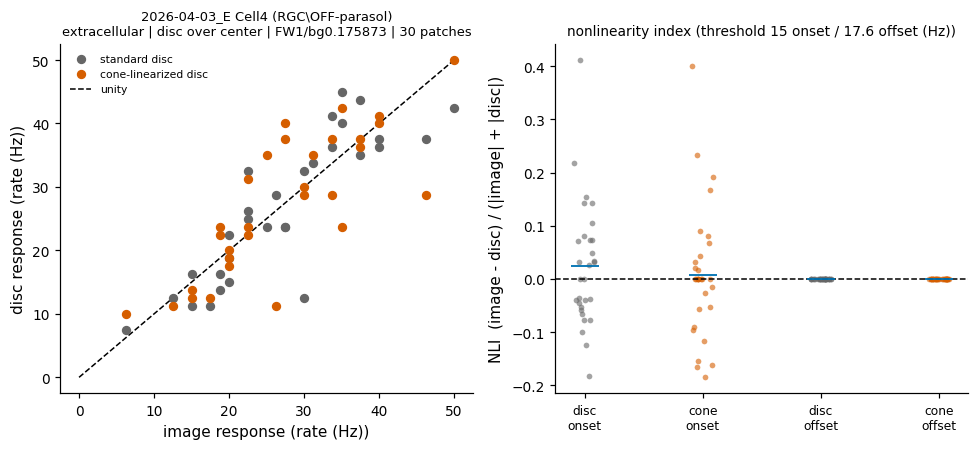

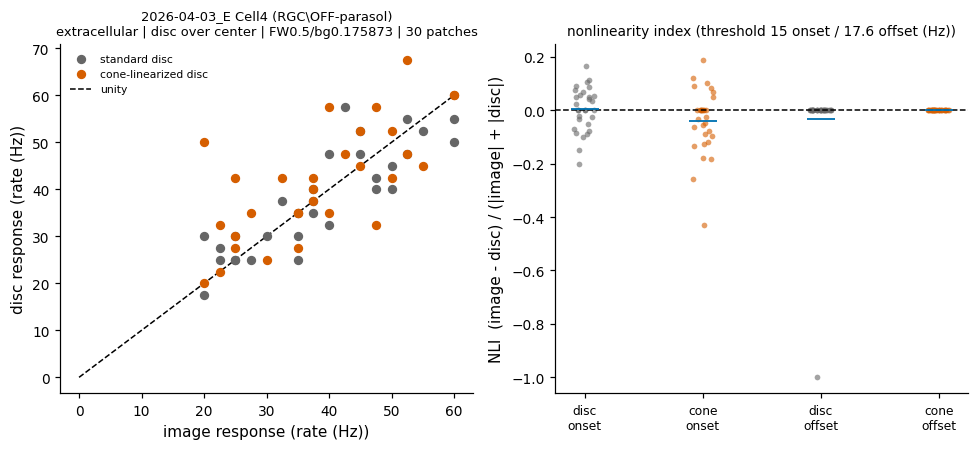

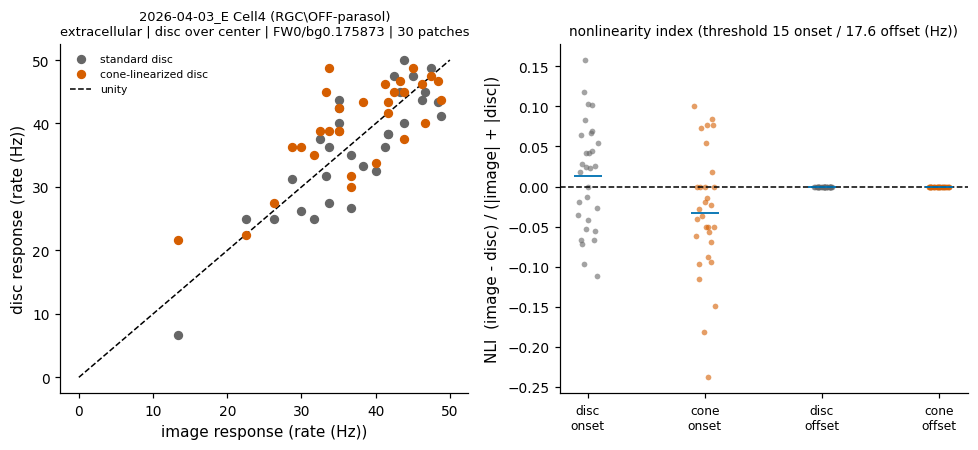

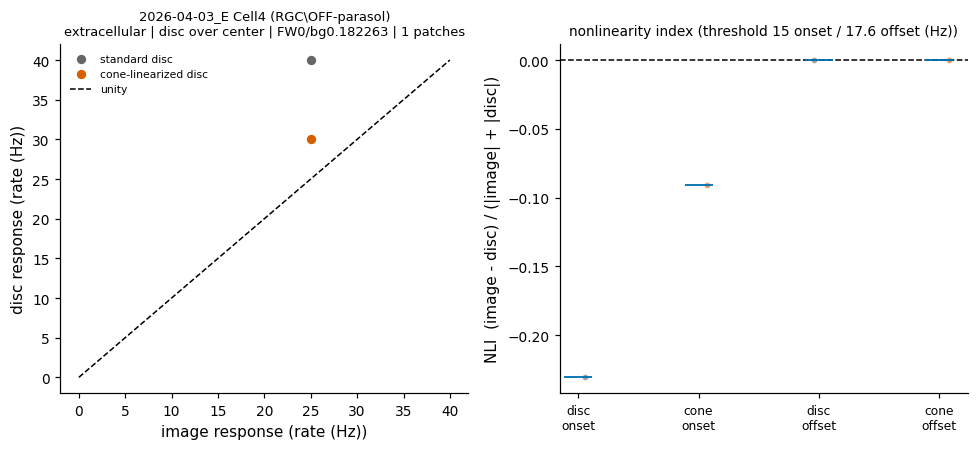

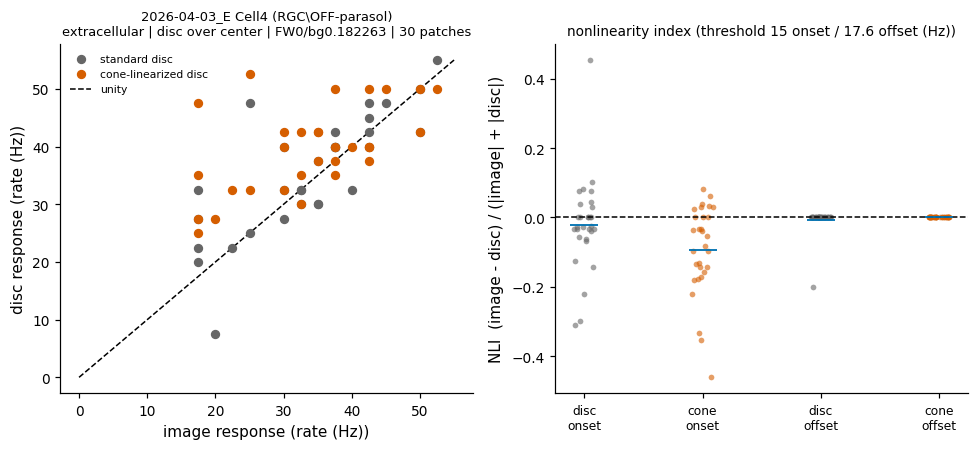

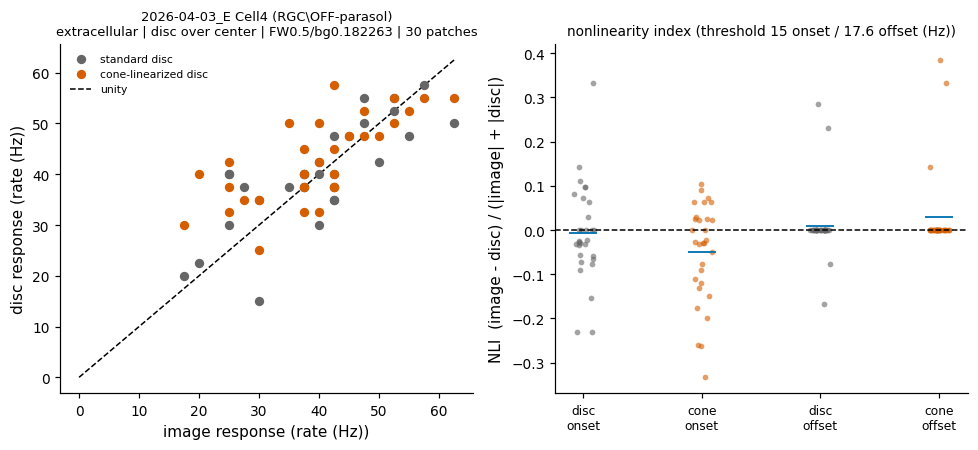

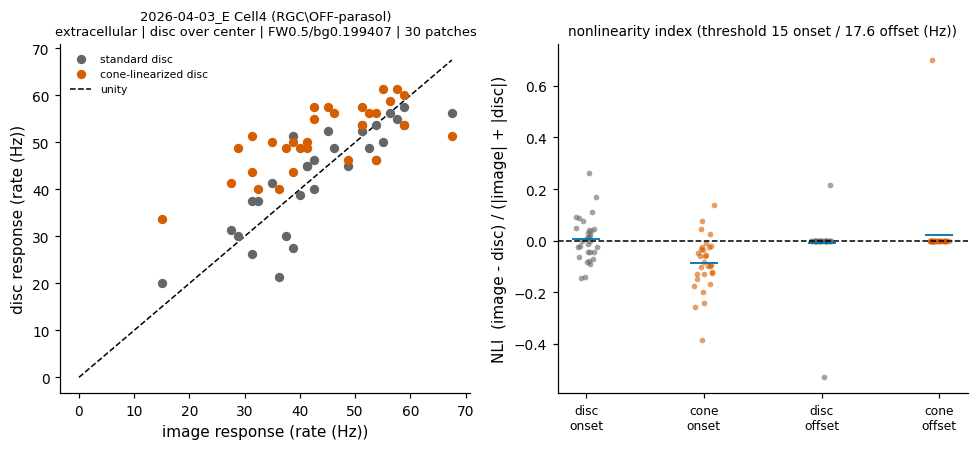

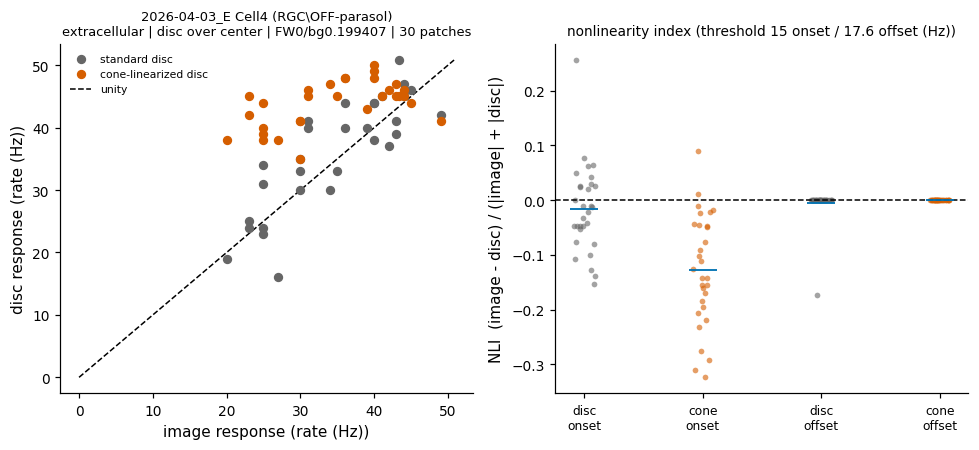

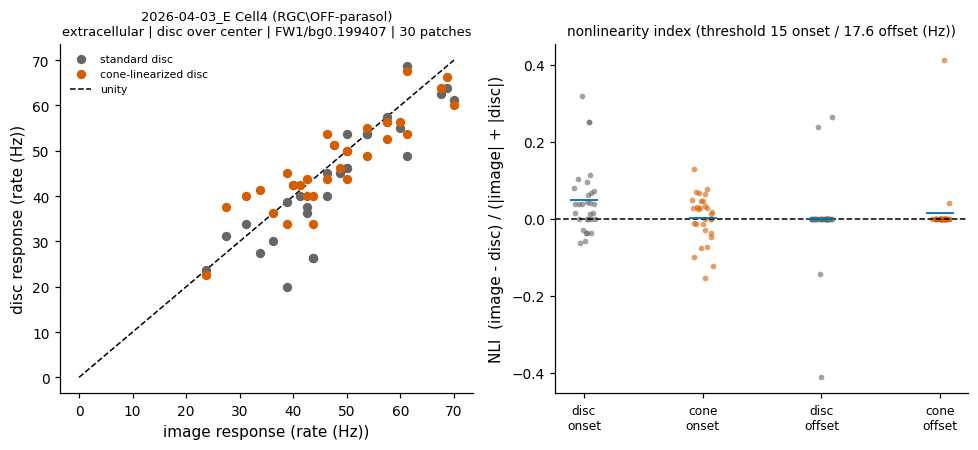

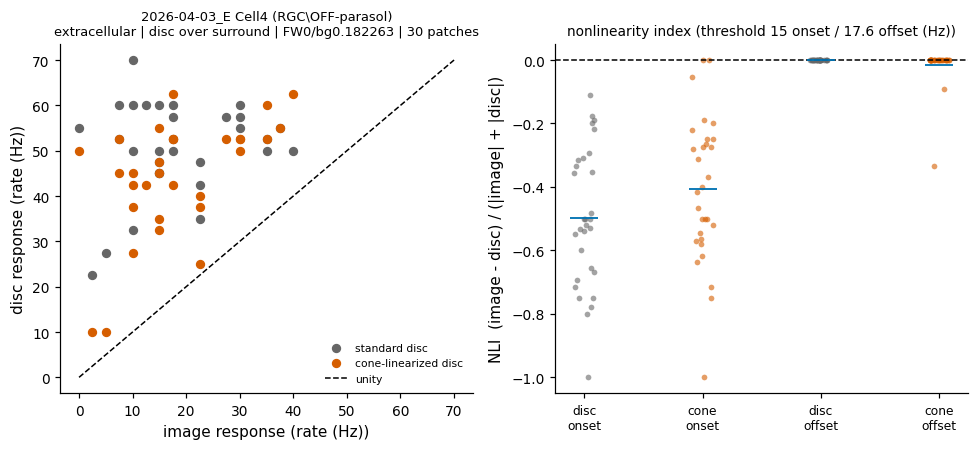

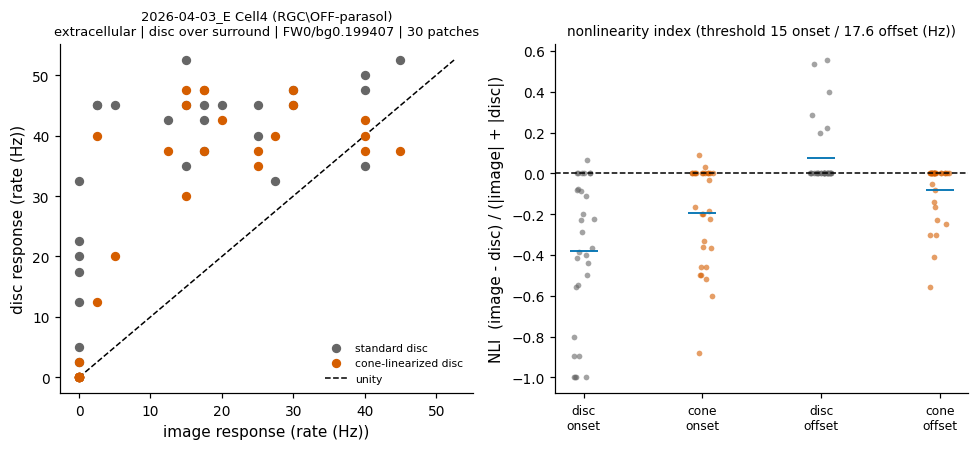

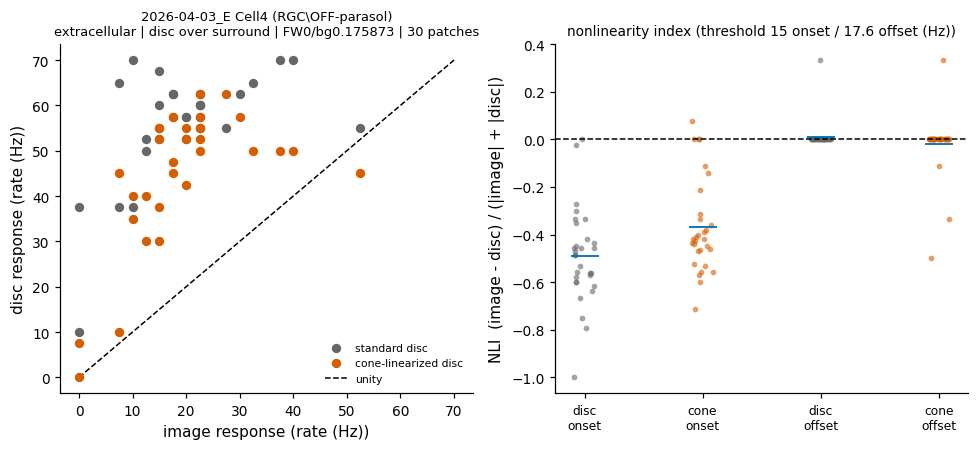

In [14]:
# Change CELL to inspect a different one. Each condition is analyzed and
# plotted in turn, and the records are returned for further poking.
CELL = '2026-04-03_E/Cell4'

cell_records = led.inspect_cell(CELL, groups)